# Building ANN with Pytorch

## Dataset

- For this, I amh going to use `Fashion MNIST data` from Kaggle, which has collection of 70,000 images, has 10 classes, which makes it mutlticlass Classification

## Workflow

- Split data into batches of 6000 images using `Dataloader`
- Run a Training Loop
- Evaluate

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [5]:
df = pd.read_csv('data/fmnist_small.csv')
df.head(1)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0


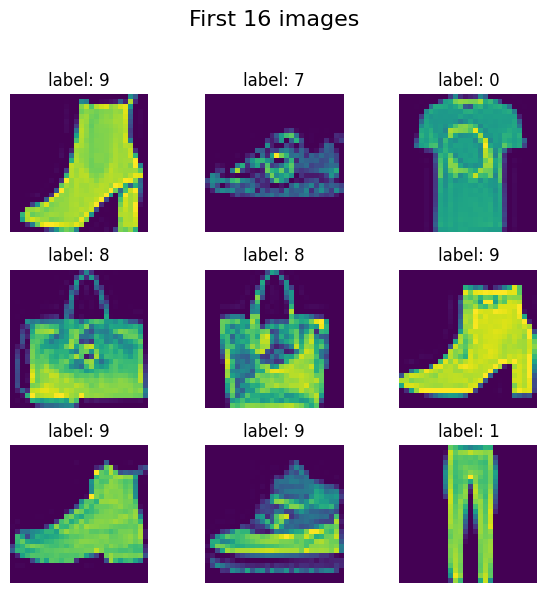

In [15]:
fig, axes = plt.subplots(3,3, figsize=(6,6))
fig.suptitle('First 16 images', fontsize=16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"label: {df.iloc[i,0]}")

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

In [17]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [22]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [23]:
#scaling the values
X_train = X_train/255.0
X_test = X_test/255.0

In [25]:
#Create custom dataset

class CustomDataset(Dataset):
    def __init__(self,features,label):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.label = torch.tensor(label, dtype=torch.long)

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.label[index]

In [26]:
#create train dataset
train_dataset = CustomDataset(X_train, y_train)

In [27]:
#create test dataset
test_dataset = CustomDataset(X_test,y_test)

In [35]:
#create train and test loader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [36]:
#define nn class
class Mynn(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [37]:
#set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [38]:
#instantiate the model
model = Mynn(X_train.shape[1])

#loss function 
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), learning_rate)

In [40]:
#training loop

for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_label in train_loader:
        #forwardpass
        outputs = model(batch_features)
        #calculate loss
        loss = criterion(outputs, batch_label)
        #backpass
        optimizer.zero_grad()
        loss.backward()
        #updateparams
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1}, Loss:{avg_loss:.4f}')
    

Epoch: 1, Loss:0.1003
Epoch: 2, Loss:0.0237
Epoch: 3, Loss:0.0246
Epoch: 4, Loss:0.0166
Epoch: 5, Loss:0.0061
Epoch: 6, Loss:0.0046
Epoch: 7, Loss:0.0035
Epoch: 8, Loss:0.0034
Epoch: 9, Loss:0.0029
Epoch: 10, Loss:0.0023
Epoch: 11, Loss:0.0023
Epoch: 12, Loss:0.0021
Epoch: 13, Loss:0.0020
Epoch: 14, Loss:0.0019
Epoch: 15, Loss:0.0021
Epoch: 16, Loss:0.0019
Epoch: 17, Loss:0.0016
Epoch: 18, Loss:0.0015
Epoch: 19, Loss:0.0015
Epoch: 20, Loss:0.0014
Epoch: 21, Loss:0.0014
Epoch: 22, Loss:0.0012
Epoch: 23, Loss:0.0012
Epoch: 24, Loss:0.0011
Epoch: 25, Loss:0.0011
Epoch: 26, Loss:0.0010
Epoch: 27, Loss:0.0010
Epoch: 28, Loss:0.0010
Epoch: 29, Loss:0.0009
Epoch: 30, Loss:0.0009
Epoch: 31, Loss:0.0009
Epoch: 32, Loss:0.0009
Epoch: 33, Loss:0.0008
Epoch: 34, Loss:0.0008
Epoch: 35, Loss:0.0008
Epoch: 36, Loss:0.0008
Epoch: 37, Loss:0.0008
Epoch: 38, Loss:0.0007
Epoch: 39, Loss:0.0007
Epoch: 40, Loss:0.0007
Epoch: 41, Loss:0.0007
Epoch: 42, Loss:0.0007
Epoch: 43, Loss:0.0007
Epoch: 44, Loss:0.00

In [41]:
#set model to eval mode

model.eval()

Mynn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [43]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_label in test_loader:
        output = model(batch_features)
        _, predicted = torch.max(output,1)
        
        total = total + batch_label.shape[0]
        correct = correct + (predicted == batch_label).sum().item()
    
print(correct/total)


0.8383333333333334
